<a href="https://colab.research.google.com/github/athiphat67/CN240_DATA-SCIENCE-FOR-SIGNAL-PROCESSING_PROJECT/blob/athiphat-develop/Src/Phase2_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 2 — Exploratory Data Analysis (EDA)

# Section 1 : Load Raw Data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download raw data files from Google Drive
!gdown "https://drive.google.com/uc?id=1Msd0tWA_fRATL1E3xn6D8clH2GxFNXn3" -O XAUUSD_Daily.csv
!gdown "https://drive.google.com/uc?id=1o78eX2lyMI_JKdMZV9HG1cGaKt5MSrSS" -O USDTHB_Daily.csv
!gdown "https://drive.google.com/uc?id=1M-C3GMQDAV7ruzKJsySEvPvWJCLib603" -O VIX_History.csv

# Load into DataFrames
xauusd_df = pd.read_csv('XAUUSD_Daily.csv', sep='\t')
usdthb_df = pd.read_csv('USDTHB_Daily.csv', sep='\t')
vix_df    = pd.read_csv('VIX_History.csv')

print("")
print("✅ Raw data loaded successfully")
print(f"   XAU/USD : {xauusd_df.shape[0]:,} rows, {xauusd_df.shape[1]} columns")
print(f"   USD/THB : {usdthb_df.shape[0]:,} rows, {usdthb_df.shape[1]} columns")
print(f"   VIX     : {vix_df.shape[0]:,} rows, {vix_df.shape[1]} columns")

Downloading...
From: https://drive.google.com/uc?id=1Msd0tWA_fRATL1E3xn6D8clH2GxFNXn3
To: /content/XAUUSD_Daily.csv
100% 307k/307k [00:00<00:00, 80.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1o78eX2lyMI_JKdMZV9HG1cGaKt5MSrSS
To: /content/USDTHB_Daily.csv
100% 210k/210k [00:00<00:00, 96.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1M-C3GMQDAV7ruzKJsySEvPvWJCLib603
To: /content/VIX_History.csv
100% 466k/466k [00:00<00:00, 117MB/s]

✅ Raw data loaded successfully
   XAU/USD : 5,538 rows, 8 columns
   USD/THB : 3,942 rows, 8 columns
   VIX     : 9,147 rows, 5 columns


## Section 2 : Inspect Raw Data Structure & Metadata


### Section 2.1 : Preview
Column names, date format, value format



In [17]:
# XAU_USD
print("=" * 60)
print("XAU/USD - First 5 rows")
print("=" * 60)
print(xauusd_df.head())

# USD_THB
print("\n" + "=" * 60)
print("USD/THB - First 5 rows")
print("=" * 60)
print(usdthb_df.head())

# VIX
print("\n" + "=" * 60)
print("VIX - First 5 rows")
print("=" * 60)
print(vix_df.head())

XAU/USD - First 5 rows
       <DATE>  <OPEN>  <HIGH>  <LOW>  <CLOSE>  <TICKVOL>  <VOL>  <SPREAD>
0  2004.06.11   384.0   384.8  382.8    384.1        303      0         0
1  2004.06.14   384.3   385.8  381.8    382.8       1954      0         0
2  2004.06.15   382.8   388.8  381.1    388.6       1995      0         0
3  2004.06.16   387.1   389.8  382.6    383.8       2106      0         0
4  2004.06.17   383.6   389.3  383.0    387.6       1638      0         0

USD/THB - First 5 rows
       <DATE>  <OPEN>  <HIGH>   <LOW>  <CLOSE>  <TICKVOL>  <VOL>  <SPREAD>
0  2011.06.02  30.210  30.240  30.180   30.205        710      0         0
1  2011.06.03  30.200  30.255  30.175   30.175        490      0         0
2  2011.06.05  30.150  30.180  30.135   30.140         63      0         0
3  2011.06.06  30.155  30.205  30.150   30.185        373      0         0
4  2011.06.07  30.190  30.235  30.155   30.175        536      0         0

VIX - First 5 rows
         DATE   OPEN   HIGH    LOW  CLO

### Section 2.2 : Schema
Data types per column

In [18]:
#
print("=" * 60)
print("XAU/USD - Schema")
print("=" * 60)
print(xauusd_df.dtypes)

print("\n" + "=" * 60)
print("USD/THB - Schema")
print("=" * 60)
print(usdthb_df.dtypes)

print("\n" + "=" * 60)
print("VIX - Schema")
print("=" * 60)
print(vix_df.dtypes)

XAU/USD - Schema
<DATE>        object
<OPEN>       float64
<HIGH>       float64
<LOW>        float64
<CLOSE>      float64
<TICKVOL>      int64
<VOL>          int64
<SPREAD>       int64
dtype: object

USD/THB - Schema
<DATE>        object
<OPEN>       float64
<HIGH>       float64
<LOW>        float64
<CLOSE>      float64
<TICKVOL>      int64
<VOL>          int64
<SPREAD>       int64
dtype: object

VIX - Schema
DATE      object
OPEN     float64
HIGH     float64
LOW      float64
CLOSE    float64
dtype: object



### Section 2.3.1 — Basic Statistics

Compute count, mean, std, min, and max for the close price of each dataset.

Goal: spot impossible values such as negative prices or zero readings.



In [19]:
datasets = [("XAU/USD", xauusd_df, '<CLOSE>'),
            ("USD/THB", usdthb_df, '<CLOSE>'),
            ("VIX",     vix_df,    'CLOSE')]

for name, df, col in datasets:
    print("=" * 60)
    print(f"{name} — Basic Statistics")
    print("=" * 60)
    display(df[[col]].describe().round(4))

XAU/USD — Basic Statistics


,<CLOSE>
count,5538.0000
mean,1415.3121
std,668.3622
min,382.8000
25%,1064.7400
50%,1302.4350
75%,1749.6025
max,4533.3200


USD/THB — Basic Statistics


,<CLOSE>
count,3942.0000
mean,32.8178
std,1.9465
min,28.5310
25%,31.2298
50%,32.5644
75%,34.4056
max,38.3329


VIX — Basic Statistics


,CLOSE
count,9147.0000
mean,19.4492
std,7.7615
min,9.1400
25%,13.9500
50%,17.6000
75%,22.7300
max,82.6900


### Section 2.3.2 — Outlier Detection
Method: IQR (numeric summary) + Boxplot (visual)

In [20]:
print("=" * 60)
print("Outlier Detection (IQR Method)")
print("=" * 60)

for name, df, col in datasets:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower    = Q1 - 1.5 * IQR
    upper    = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    flag = "⚠️" if len(outliers) > 0 else "✅"
    print(f"\n{flag} {name}")
    print(f"   Lower bound : {lower:.4f}")
    print(f"   Upper bound : {upper:.4f}")
    print(f"   Outliers    : {len(outliers)} rows ({len(outliers)/len(df)*100:.2f}%)")

    if len(outliers) > 0:
        date_col = '<DATE>' if '<DATE>' in df.columns else 'DATE'
        print(outliers[[date_col, col]].head(3).to_string(index=False))

Outlier Detection (IQR Method)

⚠️ XAU/USD
   Lower bound : 37.4462
   Upper bound : 2776.8963
   Outliers    : 239 rows (4.32%)
    <DATE>  <CLOSE>
2024.10.30  2787.21
2025.01.30  2794.06
2025.01.31  2798.47

✅ USD/THB
   Lower bound : 26.4662
   Upper bound : 39.1693
   Outliers    : 0 rows (0.00%)

⚠️ VIX
   Lower bound : 0.7800
   Upper bound : 35.9000
   Outliers    : 322 rows (3.52%)
      DATE  CLOSE
08/06/1990  35.91
08/23/1990  36.47
01/14/1991  36.20


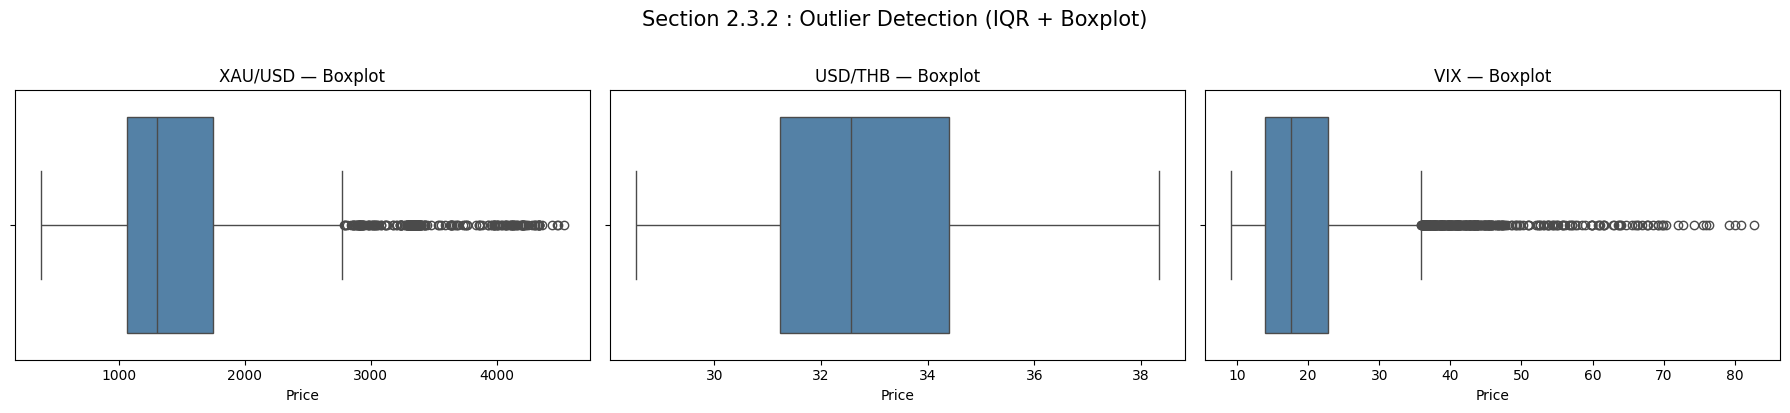

In [21]:
# Boxplot — visual confirmation of IQR result above
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, (name, df, col) in zip(axes, datasets):
    sns.boxplot(x=df[col], ax=ax, color='steelblue')
    ax.set_title(f"{name} — Boxplot")
    ax.set_xlabel("Price")

plt.suptitle("Section 2.3.2 : Outlier Detection (IQR + Boxplot)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Section 2.3.3 — Distribution Shape (Skewness & Kurtosis)

| Metric | Interpretation |
|--------|---------------|
| Skewness = 0 | Symmetric distribution |
| Skewness > 0 | Right-skewed — long right tail |
| Skewness < 0 | Left-skewed — long left tail |
| Kurtosis ~ 3 | Normal distribution |
| Kurtosis > 3 | Fat tails — extreme events are more likely than normal |

Financial data typically shows high kurtosis (fat tails),
meaning large price swings occur more often than a normal
distribution would predict.

In [22]:
print("=" * 60)
print("Distribution Shape — Skewness & Kurtosis")
print("=" * 60)

for name, df, col in datasets:
    skew = df[col].skew()
    kurt = df[col].kurt()

    skew_flag = "⚠️  right-skewed" if skew >  1 else \
                "⚠️  left-skewed"  if skew < -1 else \
                "✅  approx. symmetric"

    kurt_flag = "⚠️  fat tails — extreme events likely" if kurt > 3 else \
                "✅  normal tails"

    print(f"\n{name}")
    print(f"   Skewness : {skew:+.4f}  →  {skew_flag}")
    print(f"   Kurtosis : {kurt:+.4f}  →  {kurt_flag}")

Distribution Shape — Skewness & Kurtosis

XAU/USD
   Skewness : +1.3470  →  ⚠️  right-skewed
   Kurtosis : +3.2839  →  ⚠️  fat tails — extreme events likely

USD/THB
   Skewness : +0.3481  →  ✅  approx. symmetric
   Kurtosis : -0.7310  →  ✅  normal tails

VIX
   Skewness : +2.2046  →  ⚠️  right-skewed
   Kurtosis : +8.6889  →  ⚠️  fat tails — extreme events likely


### Section 2.3.4 — Distribution of raw close price per dataset
Method: Histogram + KDE + Rug (combined) as per lecture slides

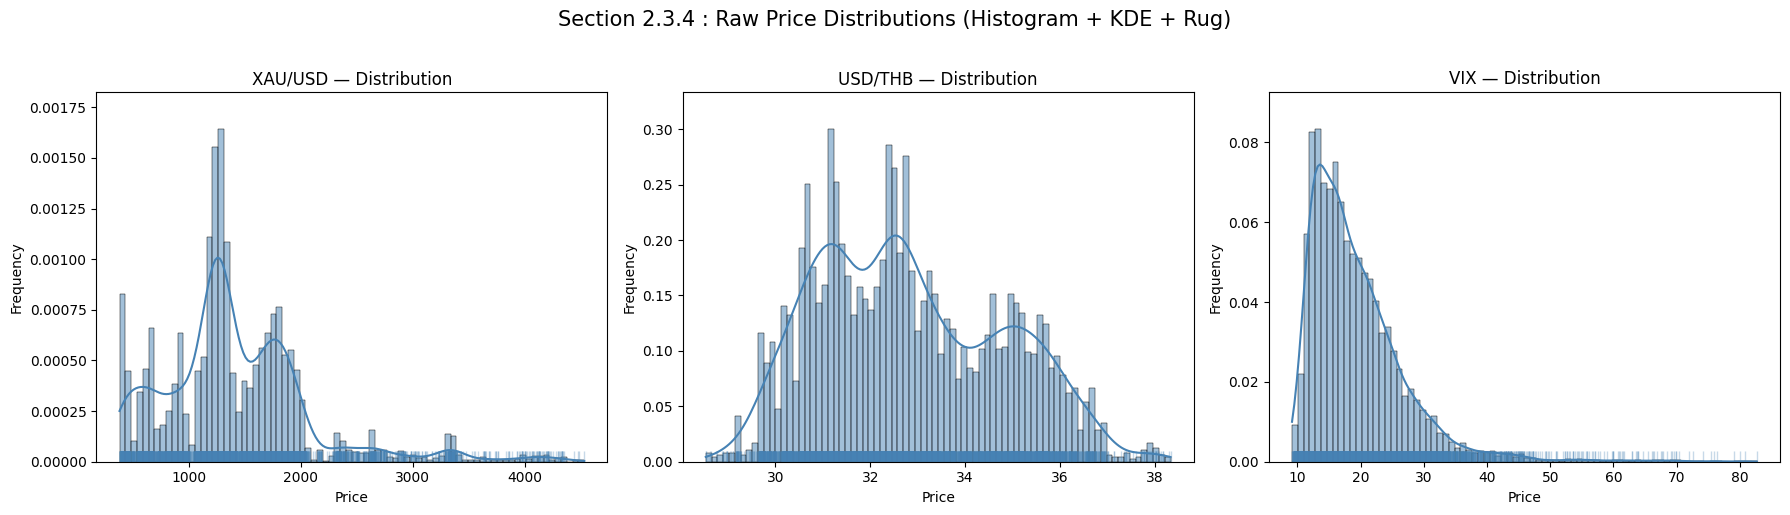

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, df, col) in zip(axes, datasets):
    sns.histplot(df[col], kde=True, bins=80, stat='density',
                 ax=ax, color='steelblue', alpha=0.5)
    sns.rugplot(df[col], ax=ax, color='steelblue', height=0.03, alpha=0.3)
    ax.set_title(f"{name} — Distribution")
    ax.set_xlabel("Price")
    ax.set_ylabel("Frequency")

plt.suptitle("Section 2.3.4 : Raw Price Distributions (Histogram + KDE + Rug)",
             fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Section 2.3.5 — Raw price trends over time
Method: Line plot as per lecture slides

Goal : verify date range and spot anomalies (e.g. USD/THB spike)

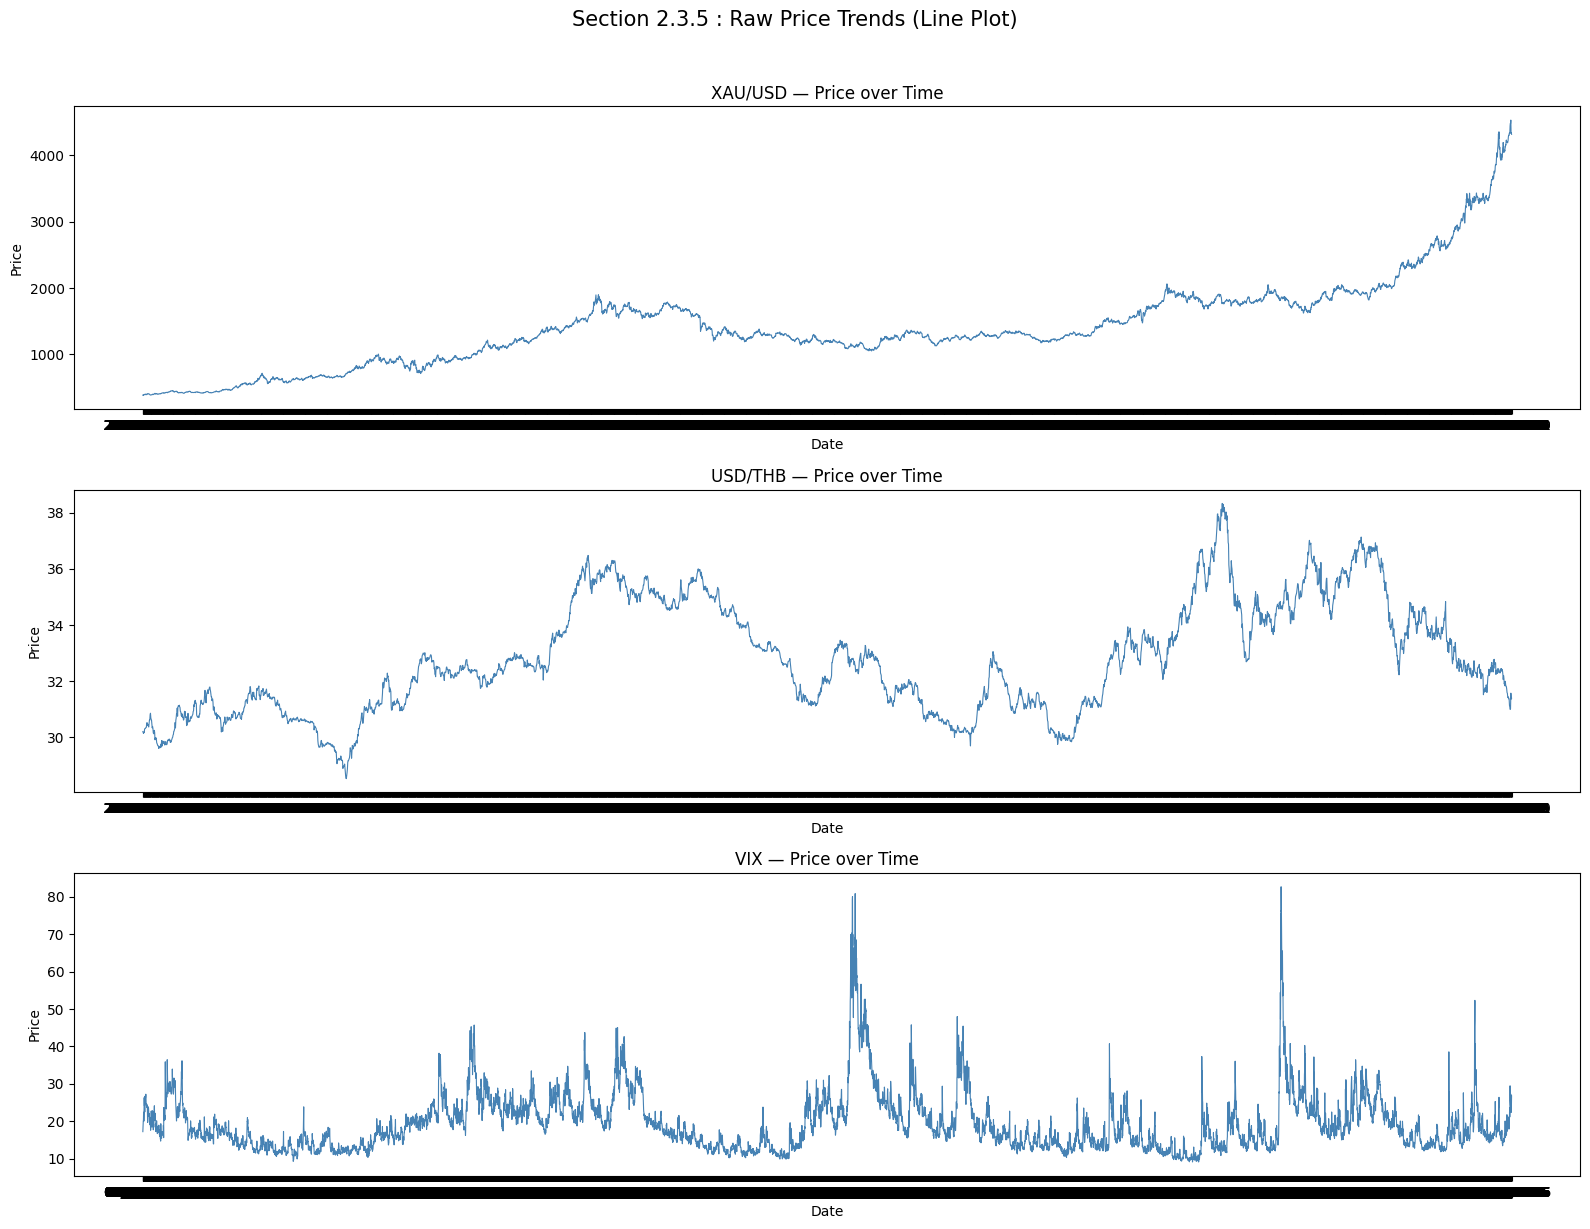

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (name, df, col) in zip(axes, datasets):
    date_col = '<DATE>' if '<DATE>' in df.columns else 'DATE'
    ax.plot(df[date_col], df[col], linewidth=0.8, color='steelblue')
    ax.set_title(f"{name} — Price over Time")
    ax.set_xlabel("Date")
    ax.set_ylabel("Price")

plt.suptitle("Section 2.3.5 : Raw Price Trends (Line Plot)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### Section 2.4 — Missing Values
Goal: know data quality before merging

In [25]:
print("Missing values per column\n")

for name, df in [("XAU/USD", xauusd_df),
                 ("USD/THB", usdthb_df),
                 ("VIX",     vix_df)]:
    missing = df.isnull().sum()
    total   = len(df)
    print(f"{'=' * 40}")
    print(f"{name}")
    print(f"{'=' * 40}")
    for col in df.columns:
        count = missing[col]
        pct   = count / total * 100
        flag  = " ⚠️" if count > 0 else " ✅"
        print(f"  {col:<20} {count:>5} missing ({pct:.1f}%){flag}")

Missing values per column

XAU/USD
  <DATE>                   0 missing (0.0%) ✅
  <OPEN>                   0 missing (0.0%) ✅
  <HIGH>                   0 missing (0.0%) ✅
  <LOW>                    0 missing (0.0%) ✅
  <CLOSE>                  0 missing (0.0%) ✅
  <TICKVOL>                0 missing (0.0%) ✅
  <VOL>                    0 missing (0.0%) ✅
  <SPREAD>                 0 missing (0.0%) ✅
USD/THB
  <DATE>                   0 missing (0.0%) ✅
  <OPEN>                   0 missing (0.0%) ✅
  <HIGH>                   0 missing (0.0%) ✅
  <LOW>                    0 missing (0.0%) ✅
  <CLOSE>                  0 missing (0.0%) ✅
  <TICKVOL>                0 missing (0.0%) ✅
  <VOL>                    0 missing (0.0%) ✅
  <SPREAD>                 0 missing (0.0%) ✅
VIX
  DATE                     0 missing (0.0%) ✅
  OPEN                     0 missing (0.0%) ✅
  HIGH                     0 missing (0.0%) ✅
  LOW                      0 missing (0.0%) ✅
  CLOSE                    0 miss